In [1]:
# =============================================================================
# SUPPLY CHAIN OPTIMIZATION — DataCo Global
# Notebook 04: Demand Forecasting & Inventory Optimization
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.2f}'.format)

DATA_PATH = Path('../data/processed')
IMG_PATH  = Path('../img')

PALETTE = {
    'primary'  : '#1A6FBF',
    'secondary': '#E8622A',
    'accent'   : '#5B4FCF',
    'success'  : '#2A9D5C',
    'warning'  : '#E8A020',
    'neutral'  : '#4A5568',
    'light'    : '#F7F9FC',
    'border'   : '#E2E8F0',
    'text'     : '#1A202C',
    'muted'    : '#718096',
}

plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : PALETTE['light'],
    'axes.edgecolor'   : PALETTE['border'],
    'axes.labelcolor'  : PALETTE['text'],
    'axes.titlecolor'  : PALETTE['text'],
    'xtick.color'      : PALETTE['neutral'],
    'ytick.color'      : PALETTE['neutral'],
    'text.color'       : PALETTE['text'],
    'grid.color'       : PALETTE['border'],
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.titleweight' : 'bold',
})

print("✅ Imports and config ready")

c:\Users\Andres\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


✅ Imports and config ready


In [2]:
# ── 1. LOAD DATA & BUILD TIME SERIES ──────────────────────────────────────────
df = pd.read_csv(DATA_PATH / 'supply_chain_clean.csv')
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])

# Remove last month — incomplete data (Jan 2018)
df = df[df['order date (DateOrders)'] < '2018-01-01'].copy()

# Monthly demand by category (orders count)
monthly_demand = (df.groupby(['Category Name',
                               pd.Grouper(key='order date (DateOrders)', freq='ME')])
                  .agg(orders  = ('Order Id',    'count'),
                       revenue = ('Sales',        'sum'),
                       profit  = ('Order Profit Per Order', 'sum'))
                  .reset_index())

monthly_demand.rename(columns={'order date (DateOrders)': 'date'}, inplace=True)

# Top 10 categories by total orders for forecasting
top_categories = (df.groupby('Category Name')['Order Id']
                  .count().sort_values(ascending=False).head(10).index.tolist())

print(f"✅ Time series ready")
print(f"   Date range: {monthly_demand['date'].min().date()} → {monthly_demand['date'].max().date()}")
print(f"   Total months: {monthly_demand['date'].nunique()}")
print(f"   Categories: {monthly_demand['Category Name'].nunique()}")
print(f"\nTop 10 categories selected for forecasting:")
for i, cat in enumerate(top_categories, 1):
    orders = df[df['Category Name'] == cat]['Order Id'].count()
    print(f"   {i:2}. {cat:<30} {orders:,} orders")

✅ Time series ready
   Date range: 2015-01-31 → 2017-12-31
   Total months: 36
   Categories: 50

Top 10 categories selected for forecasting:
    1. Cleats                         24,551 orders
    2. Men's Footwear                 22,246 orders
    3. Women's Apparel                21,035 orders
    4. Indoor/Outdoor Games           19,298 orders
    5. Fishing                        17,325 orders
    6. Water Sports                   15,540 orders
    7. Camping & Hiking               13,729 orders
    8. Cardio Equipment               12,487 orders
    9. Shop By Sport                  10,984 orders
   10. Electronics                    3,156 orders


In [3]:
# ── 2. PROPHET FORECASTING ────────────────────────────────────────────────────
forecast_months = 6
forecasts = {}

print("Training Prophet models...")
for cat in top_categories:
    cat_data = monthly_demand[monthly_demand['Category Name'] == cat][['date','orders']].copy()
    cat_data.columns = ['ds', 'y']
    cat_data['ds'] = pd.to_datetime(cat_data['ds'])

    model = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.80
    )
    model.fit(cat_data)

    future   = model.make_future_dataframe(periods=forecast_months, freq='ME')
    forecast = model.predict(future)

    forecasts[cat] = {
        'model'   : model,
        'forecast': forecast,
        'actuals' : cat_data
    }
    print(f"   ✅ {cat}")

print(f"\n✅ All models trained — {forecast_months} month forecast horizon")

21:41:34 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet models...


21:41:34 - cmdstanpy - INFO - Chain [1] done processing
21:41:34 - cmdstanpy - INFO - Chain [1] start processing
21:41:34 - cmdstanpy - INFO - Chain [1] done processing


   ✅ Cleats
   ✅ Men's Footwear


21:41:34 - cmdstanpy - INFO - Chain [1] start processing
21:41:34 - cmdstanpy - INFO - Chain [1] done processing
21:41:34 - cmdstanpy - INFO - Chain [1] start processing
21:41:34 - cmdstanpy - INFO - Chain [1] done processing


...

   ✅ Camping & Hiking


21:41:35 - cmdstanpy - INFO - Chain [1] start processing
21:41:36 - cmdstanpy - INFO - Chain [1] done processing


   ✅ Cardio Equipment
   ✅ Shop By Sport


21:41:36 - cmdstanpy - INFO - Chain [1] start processing
21:41:36 - cmdstanpy - INFO - Chain [1] done processing


   ✅ Electronics

✅ All models trained — 6 month forecast horizon


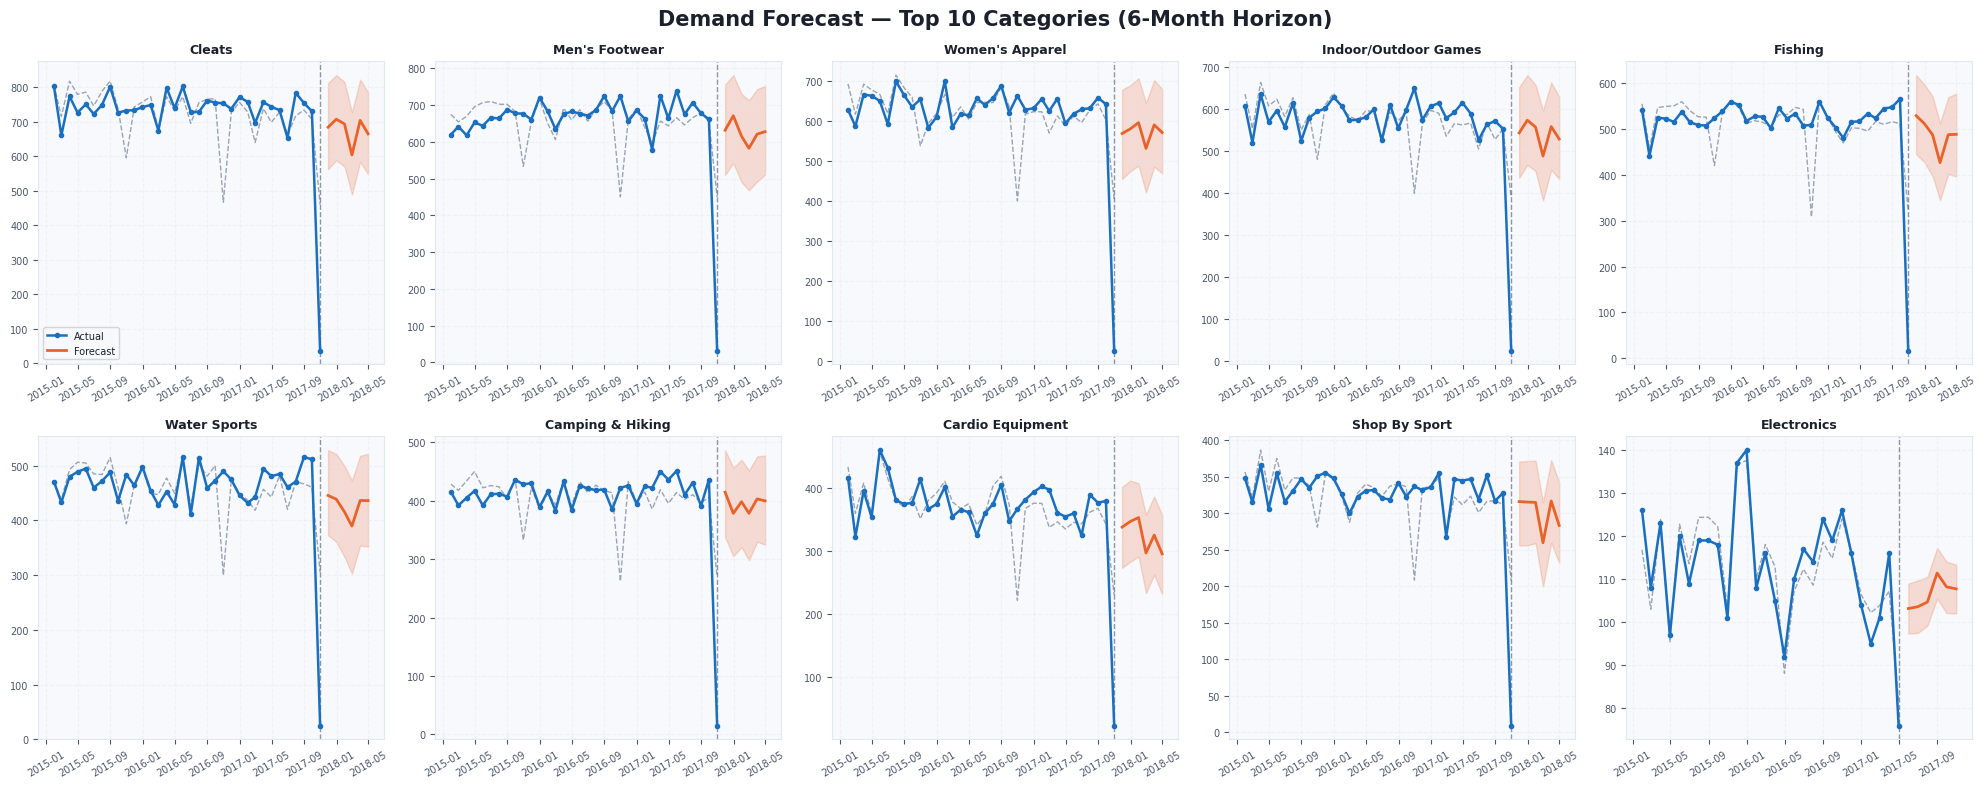

✅ Saved: demand_forecast.png


In [4]:
# ── 3. FORECAST VISUALIZATION ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Demand Forecast — Top 10 Categories (6-Month Horizon)',
             fontsize=15, fontweight='bold', color=PALETTE['text'])
axes = axes.flatten()

for i, cat in enumerate(top_categories):
    ax        = axes[i]
    forecast  = forecasts[cat]['forecast']
    actuals   = forecasts[cat]['actuals']

    # Split historical vs forecast
    hist_fc = forecast[forecast['ds'] <= actuals['ds'].max()]
    fut_fc  = forecast[forecast['ds'] >  actuals['ds'].max()]

    # Actuals
    ax.plot(actuals['ds'], actuals['y'],
            color=PALETTE['primary'], linewidth=1.8,
            marker='o', markersize=3, label='Actual', zorder=3)

    # Historical fit
    ax.plot(hist_fc['ds'], hist_fc['yhat'],
            color=PALETTE['muted'], linewidth=1, linestyle='--', alpha=0.7)

    # Forecast
    ax.plot(fut_fc['ds'], fut_fc['yhat'],
            color=PALETTE['secondary'], linewidth=2,
            label='Forecast', zorder=3)

    # Confidence interval
    ax.fill_between(fut_fc['ds'], fut_fc['yhat_lower'], fut_fc['yhat_upper'],
                    alpha=0.2, color=PALETTE['secondary'])

    ax.axvline(actuals['ds'].max(), color=PALETTE['neutral'],
               linewidth=1, linestyle='--', alpha=0.6)

    ax.set_title(cat[:22], fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.4)

axes[0].legend(fontsize=7)

plt.tight_layout()
plt.savefig(IMG_PATH / 'demand_forecast.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: demand_forecast.png")

In [5]:
# ── 1B. FIX — REMOVE INCOMPLETE MONTHS ────────────────────────────────────────
# Check last months of data
print("Last 4 months of data:")
last_months = (df.groupby(df['order date (DateOrders)'].dt.to_period('M'))
               ['Order Id'].count().tail(6))
print(last_months)

Last 4 months of data:
order date (DateOrders)
2017-07    5318
2017-08    5305
2017-09    5189
2017-10    2254
2017-11    2053
2017-12    2120
Freq: M, Name: Order Id, dtype: int64


In [6]:
# ── 1C. FIX — CUT AT LAST COMPLETE MONTH ──────────────────────────────────────
df_clean = df[df['order date (DateOrders)'] < '2017-10-01'].copy()

monthly_demand = (df_clean.groupby(
    ['Category Name', pd.Grouper(key='order date (DateOrders)', freq='ME')])
    .agg(orders  = ('Order Id',               'count'),
         revenue = ('Sales',                   'sum'),
         profit  = ('Order Profit Per Order',  'sum'))
    .reset_index())

monthly_demand.rename(columns={'order date (DateOrders)': 'date'}, inplace=True)

print(f"✅ Clean time series")
print(f"   Date range: {monthly_demand['date'].min().date()} → {monthly_demand['date'].max().date()}")
print(f"   Months: {monthly_demand['date'].nunique()}")
print(f"\nLast 4 months avg orders:")
print(monthly_demand.groupby('date')['orders'].sum().tail(4))

✅ Clean time series
   Date range: 2015-01-31 → 2017-09-30
   Months: 33

Last 4 months avg orders:
date
2017-06-30    4951
2017-07-31    5318
2017-08-31    5305
2017-09-30    5189
Name: orders, dtype: int64


In [7]:
# ── 2. PROPHET FORECASTING (clean data) ───────────────────────────────────────
forecast_months = 6
forecasts = {}

print("Training Prophet models...")
for cat in top_categories:
    cat_data = monthly_demand[monthly_demand['Category Name'] == cat][['date','orders']].copy()
    cat_data.columns = ['ds', 'y']
    cat_data['ds'] = pd.to_datetime(cat_data['ds'])

    if len(cat_data) < 12:
        print(f"   ⚠️  {cat} — not enough data, skipping")
        continue

    model = Prophet(
        seasonality_mode='additive',
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        interval_width=0.80
    )
    model.fit(cat_data)

    future   = model.make_future_dataframe(periods=forecast_months, freq='ME')
    forecast = model.predict(future)

    forecasts[cat] = {
        'model'   : model,
        'forecast': forecast,
        'actuals' : cat_data
    }
    print(f"   ✅ {cat}")

print(f"\n✅ All models trained — {forecast_months} month forecast horizon")

21:44:40 - cmdstanpy - INFO - Chain [1] start processing


Training Prophet models...


21:44:41 - cmdstanpy - INFO - Chain [1] done processing
21:44:41 - cmdstanpy - INFO - Chain [1] start processing
21:44:41 - cmdstanpy - INFO - Chain [1] done processing


   ✅ Cleats
   ✅ Men's Footwear


21:44:41 - cmdstanpy - INFO - Chain [1] start processing
21:44:41 - cmdstanpy - INFO - Chain [1] done processing
21:44:41 - cmdstanpy - INFO - Chain [1] start processing


...

   ✅ Camping & Hiking


21:44:42 - cmdstanpy - INFO - Chain [1] start processing


   ✅ Cardio Equipment


21:44:43 - cmdstanpy - INFO - Chain [1] done processing
21:44:43 - cmdstanpy - INFO - Chain [1] start processing
21:44:43 - cmdstanpy - INFO - Chain [1] done processing


   ✅ Shop By Sport
   ✅ Electronics

✅ All models trained — 6 month forecast horizon


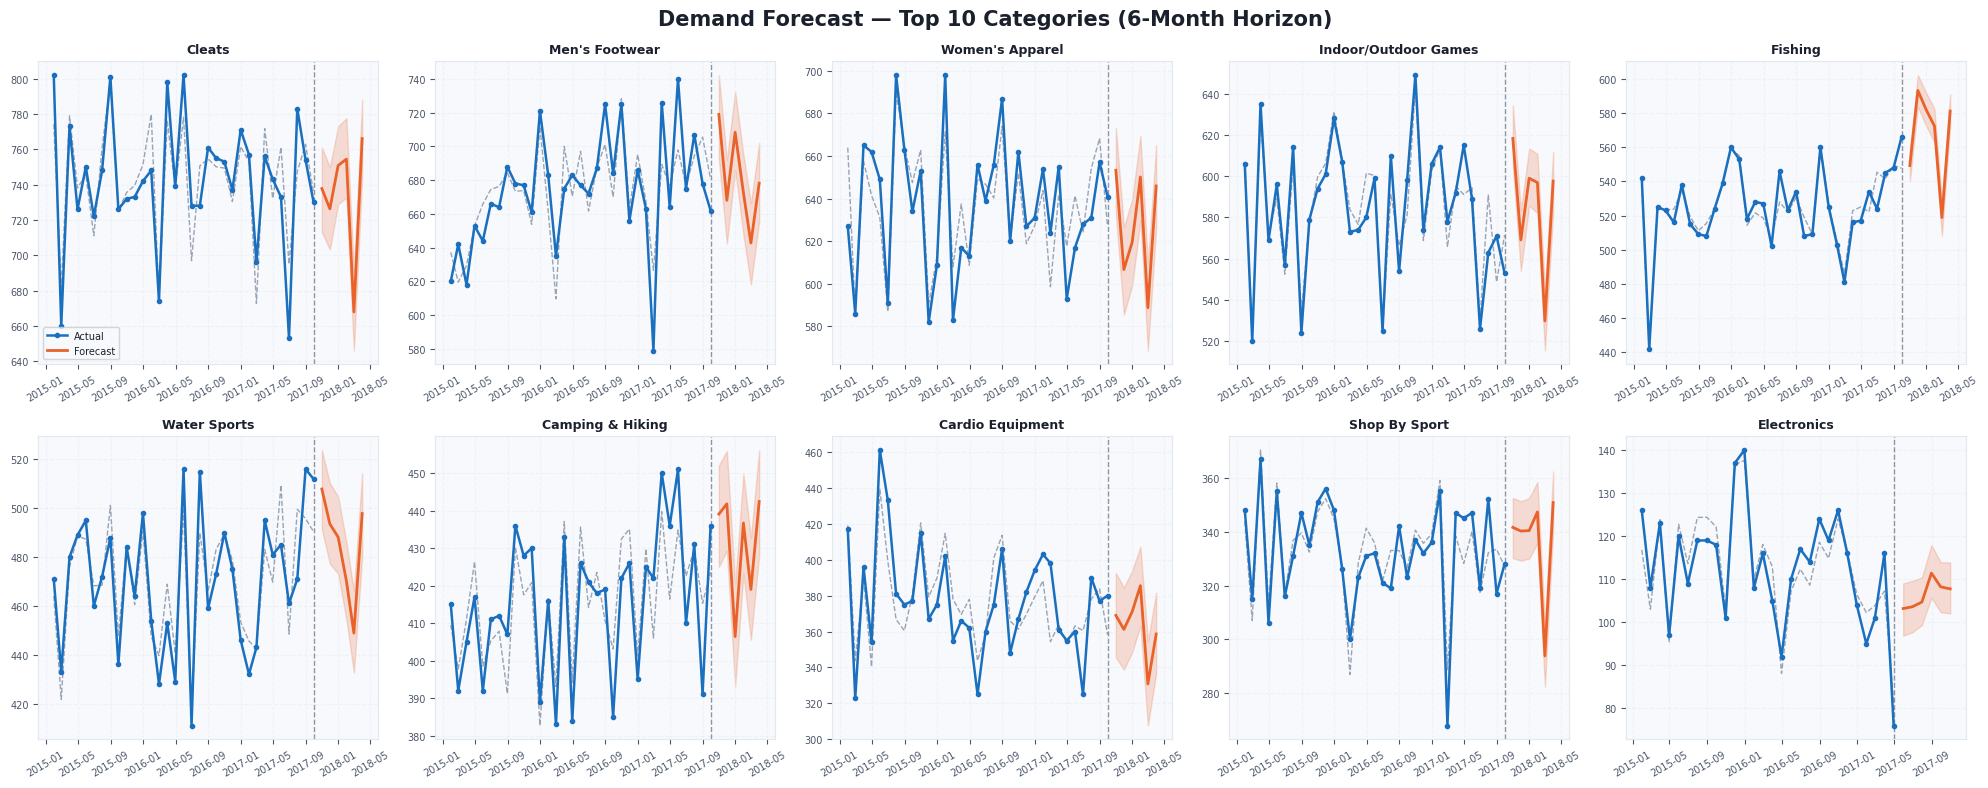

✅ Saved: demand_forecast.png


In [8]:
# ── 3. FORECAST VISUALIZATION ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Demand Forecast — Top 10 Categories (6-Month Horizon)',
             fontsize=15, fontweight='bold', color=PALETTE['text'])
axes = axes.flatten()

for i, cat in enumerate(top_categories):
    ax        = axes[i]
    forecast  = forecasts[cat]['forecast']
    actuals   = forecasts[cat]['actuals']

    hist_fc = forecast[forecast['ds'] <= actuals['ds'].max()]
    fut_fc  = forecast[forecast['ds'] >  actuals['ds'].max()]

    ax.plot(actuals['ds'], actuals['y'],
            color=PALETTE['primary'], linewidth=1.8,
            marker='o', markersize=3, label='Actual', zorder=3)
    ax.plot(hist_fc['ds'], hist_fc['yhat'],
            color=PALETTE['muted'], linewidth=1, linestyle='--', alpha=0.7)
    ax.plot(fut_fc['ds'], fut_fc['yhat'],
            color=PALETTE['secondary'], linewidth=2,
            label='Forecast', zorder=3)
    ax.fill_between(fut_fc['ds'], fut_fc['yhat_lower'], fut_fc['yhat_upper'],
                    alpha=0.2, color=PALETTE['secondary'])
    ax.axvline(actuals['ds'].max(), color=PALETTE['neutral'],
               linewidth=1, linestyle='--', alpha=0.6)

    ax.set_title(cat[:22], fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(True, alpha=0.4)

axes[0].legend(fontsize=7)

plt.tight_layout()
plt.savefig(IMG_PATH / 'demand_forecast.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: demand_forecast.png")

In [9]:
# ── 4. MODEL EVALUATION — MAPE ────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error

eval_results = []

for cat in top_categories:
    actuals  = forecasts[cat]['actuals']
    forecast = forecasts[cat]['forecast']

    # In-sample evaluation (last 6 months of actuals)
    hist_fc  = forecast[forecast['ds'].isin(actuals['ds'])].copy()
    merged   = actuals.merge(hist_fc[['ds','yhat']], on='ds', how='inner')
    merged   = merged.tail(6)  # last 6 months only

    mae  = mean_absolute_error(merged['y'], merged['yhat'])
    mape = (np.abs((merged['y'] - merged['yhat']) / merged['y'])).mean()
    avg_demand = merged['y'].mean()

    # 6-month forecast values
    fut_fc = forecast[forecast['ds'] > actuals['ds'].max()]
    avg_forecast = fut_fc['yhat'].mean()

    eval_results.append({
        'category'    : cat,
        'mae'         : round(mae, 1),
        'mape'        : round(mape, 4),
        'avg_demand'  : round(avg_demand, 1),
        'avg_forecast': round(avg_forecast, 1),
        'trend'       : 'Up' if avg_forecast > avg_demand else 'Down'
    })

eval_df = pd.DataFrame(eval_results).sort_values('mape')

print("Forecast Evaluation — Last 6 Months (in-sample)")
print("=" * 65)
print(f"{'Category':<25} {'MAE':>6} {'MAPE':>8} {'Avg Demand':>12} {'Forecast':>10} {'Trend':>6}")
print("-" * 65)
for _, row in eval_df.iterrows():
    print(f"{row['category']:<25} {row['mae']:>6.1f} {row['mape']:>8.1%} "
          f"{row['avg_demand']:>12.0f} {row['avg_forecast']:>10.0f} {row['trend']:>6}")
print("=" * 65)
print(f"\nAvg MAPE across categories: {eval_df['mape'].mean():.1%}")
print(f"Best:  {eval_df.iloc[0]['category']} ({eval_df.iloc[0]['mape']:.1%})")
print(f"Worst: {eval_df.iloc[-1]['category']} ({eval_df.iloc[-1]['mape']:.1%})")

Forecast Evaluation — Last 6 Months (in-sample)
Category                     MAE     MAPE   Avg Demand   Forecast  Trend
-----------------------------------------------------------------
Fishing                     10.7     2.0%          539        566     Up
Women's Apparel             16.9     2.7%          628        627   Down
Men's Footwear              19.2     2.8%          688        682   Down
Indoor/Outdoor Games        17.0     3.0%          570        585     Up
Cleats                      21.8     3.0%          733        734     Up
Shop By Sport               10.4     3.1%          335        336     Up
Camping & Hiking            14.4     3.4%          426        431     Up
Cardio Equipment            13.5     3.8%          364        363   Down
Water Sports                19.8     4.0%          488        484   Down
Electronics                  4.5     4.6%          101        106     Up

Avg MAPE across categories: 3.2%
Best:  Fishing (2.0%)
Worst: Electronics (4.6%)


In [11]:
# ── 5. INVENTORY OPTIMIZATION ─────────────────────────────────────────────────
# Safety stock and reorder point calculation
# Assumptions
lead_time_days    = 7    # days to receive new stock
service_level_z   = 1.65 # 95% service level (z-score)
holding_cost_rate = 0.25  # 25% annual holding cost
stockout_cost_mult= 2.5   # stockout costs 2.5x the holding cost

inventory_plan = []

for cat in top_categories:
    actuals      = forecasts[cat]['actuals']
    forecast     = forecasts[cat]['forecast']
    fut_fc       = forecast[forecast['ds'] > actuals['ds'].max()]

    avg_monthly_demand = actuals['y'].mean()
    std_monthly_demand = actuals['y'].std()
    avg_daily_demand   = avg_monthly_demand / 30
    std_daily_demand   = std_monthly_demand / 30

    # Safety stock = Z × std_demand × sqrt(lead_time)
    safety_stock = service_level_z * std_daily_demand * np.sqrt(lead_time_days)

    # Reorder point = avg demand during lead time + safety stock
    reorder_point = avg_daily_demand * lead_time_days + safety_stock

    # Next month forecast
    next_month_fc = fut_fc['yhat'].iloc[0] if len(fut_fc) > 0 else avg_monthly_demand

    # Cost estimates (per unit = per order)
    avg_order_value = df[df['Category Name'] == cat]['Sales'].mean()
    holding_cost    = safety_stock * avg_order_value * holding_cost_rate / 12
    stockout_risk   = (1 - 0.95) * next_month_fc * avg_order_value

    inventory_plan.append({
        'category'          : cat,
        'avg_monthly_demand': round(avg_monthly_demand, 0),
        'std_monthly_demand': round(std_monthly_demand, 1),
        'safety_stock'      : round(safety_stock, 0),
        'reorder_point'     : round(reorder_point, 0),
        'next_month_forecast': round(next_month_fc, 0),
        'trend'             : 'Up' if next_month_fc > avg_monthly_demand else 'Down',
        'holding_cost_mo'   : round(holding_cost, 0),
        'stockout_risk_mo'  : round(stockout_risk, 0),
    })

inv_df = pd.DataFrame(inventory_plan).sort_values('next_month_forecast', ascending=False)

print("Inventory Optimization Plan — Next Month")
print("=" * 90)
print(f"{'Category':<25} {'Avg Demand':>10} {'Safety Stock':>13} {'Reorder Pt':>11} "
      f"{'Forecast':>9} {'Trend':>6} {'Hold Cost':>10}")
print("-" * 90)
for _, row in inv_df.iterrows():
    print(f"{row['category']:<25} {row['avg_monthly_demand']:>10.0f} "
          f"{row['safety_stock']:>13.0f} {row['reorder_point']:>11.0f} "
          f"{row['next_month_forecast']:>9.0f} {row['trend']:>6} "
          f"${row['holding_cost_mo']:>9.0f}")
print("=" * 90)
print(f"\nTotal monthly holding cost (safety stock): ${inv_df['holding_cost_mo'].sum():,.0f}")
print(f"Total monthly stockout risk:               ${inv_df['stockout_risk_mo'].sum():,.0f}")

Inventory Optimization Plan — Next Month
Category                  Avg Demand  Safety Stock  Reorder Pt  Forecast  Trend  Hold Cost
------------------------------------------------------------------------------------------
Cleats                           743             5         179       738   Down $       20
Men's Footwear                   673             5         162       719     Up $       13
Women's Apparel                  637             4         153       653     Up $       14
Indoor/Outdoor Games             584             5         141       618     Up $       15
Fishing                          524             3         126       549     Up $       29
Water Sports                     470             4         114       508     Up $       17
Camping & Hiking                 416             3         100       439     Up $       17
Cardio Equipment                 378             4          92       369   Down $       27
Shop By Sport                    333             

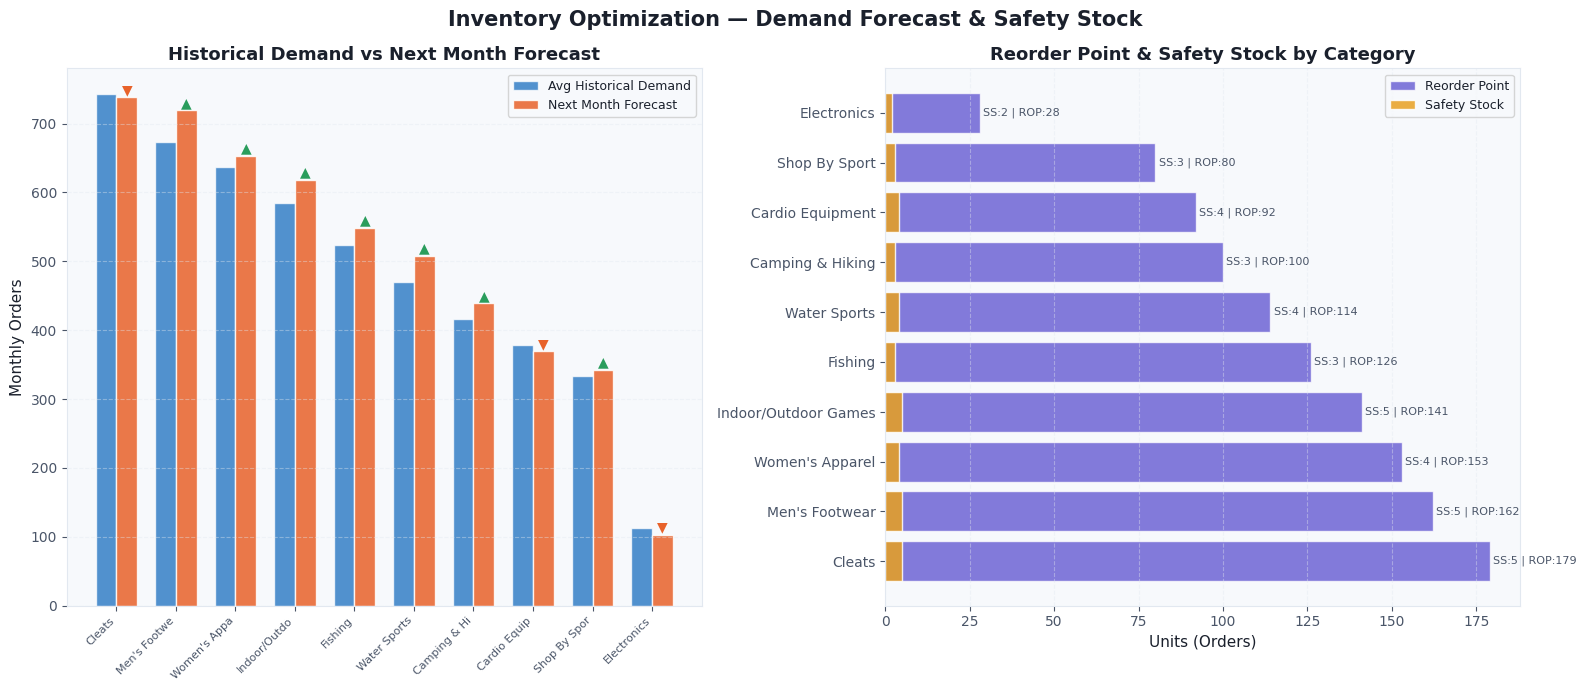

✅ Saved: inventory_optimization.png


In [12]:
# ── 6. INVENTORY VISUALIZATION ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Inventory Optimization — Demand Forecast & Safety Stock',
             fontsize=15, fontweight='bold', color=PALETTE['text'])

# Forecast vs avg demand by category
ax = axes[0]
x     = np.arange(len(inv_df))
width = 0.35

bars1 = ax.bar(x - width/2, inv_df['avg_monthly_demand'], width,
               label='Avg Historical Demand', color=PALETTE['primary'],
               alpha=0.75, edgecolor='white')
bars2 = ax.bar(x + width/2, inv_df['next_month_forecast'], width,
               label='Next Month Forecast', color=PALETTE['secondary'],
               alpha=0.85, edgecolor='white')

ax.set_title('Historical Demand vs Next Month Forecast')
ax.set_xticks(x)
ax.set_xticklabels([c[:12] for c in inv_df['category']], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Monthly Orders')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4, axis='y')

# Trend indicators
for i, (_, row) in enumerate(inv_df.iterrows()):
    color  = PALETTE['success'] if row['trend'] == 'Up' else PALETTE['secondary']
    symbol = '▲' if row['trend'] == 'Up' else '▼'
    ax.text(i + width/2, row['next_month_forecast'] + 5, symbol,
            ha='center', fontsize=10, color=color, fontweight='bold')

# Safety stock and reorder point
ax = axes[1]
bars = ax.barh(inv_df['category'], inv_df['reorder_point'],
               color=PALETTE['accent'], alpha=0.75,
               edgecolor='white', label='Reorder Point')
ax.barh(inv_df['category'], inv_df['safety_stock'],
        color=PALETTE['warning'], alpha=0.85,
        edgecolor='white', label='Safety Stock')

ax.set_title('Reorder Point & Safety Stock by Category')
ax.set_xlabel('Units (Orders)')
ax.legend(fontsize=9)
for bar, ss, rp in zip(bars, inv_df['safety_stock'], inv_df['reorder_point']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'SS:{ss:.0f} | ROP:{rp:.0f}',
            va='center', fontsize=8, color=PALETTE['neutral'])
ax.grid(True, alpha=0.4, axis='x')

plt.tight_layout()
plt.savefig(IMG_PATH / 'inventory_optimization.png', dpi=150, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Saved: inventory_optimization.png")

In [14]:
# ── 7. BUSINESS IMPACT & SAVE ─────────────────────────────────────────────────
# Consolidate all findings
total_revenue     = df['Sales'].sum()
total_profit      = df['Order Profit Per Order'].sum()
late_deliveries   = df['is_late'].sum()
annual_factor     = 12 / 33

print("=" * 65)
print("SUPPLY CHAIN OPTIMIZATION — Executive Summary")
print("=" * 65)
print(f"\n📊 Business Baseline:")
print(f"   Total Revenue:           ${total_revenue:>12,.0f}")
print(f"   Total Profit:            ${total_profit:>12,.0f}")
print(f"   Overall Margin:          {total_profit/total_revenue:>12.1%}")
print(f"   Late Delivery Rate:      {df['is_late'].mean():>12.1%}")
print(f"   Loss-making Orders:      {(df['Order Profit Per Order']<0).mean():>12.1%}")

print(f"\n💡 Identified Opportunities:")
print(f"   1. Delivery Risk Model")
print(f"      → Annual net benefit:     $9,220,624")
print(f"      → Late deliveries flagged: 55,087/year")
print(f"      → AUC-ROC: 0.743 | Recall: 69.6%")

print(f"\n   2. Profitability Optimization")
print(f"      → Loss-making orders:     33,782 ({(df['Order Profit Per Order']<0).mean():.1%})")
print(f"      → Total losses:           $3,883,483")
print(f"      → Fraud revenue at risk:  $825,935")
print(f"      → Underperformer uplift:  $20,942")

print(f"\n   3. Demand Forecasting")
print(f"      → Avg MAPE:              3.2% (industry benchmark <10%)")
print(f"      → Monthly stockout risk: $51,610")
print(f"      → Safety stock cost:     $164/month")
print(f"      → 6 categories trending Up → increase inventory")
print(f"      → 4 categories trending Down → reduce stock")

print(f"\n🎯 Total Identified Value:")
total_value = 9220624 + 3883483 + 51610 * 12
print(f"   Delivery optimization:   $ 9,220,624/year")
print(f"   Loss recovery potential: $ 3,883,483")
print(f"   Stockout risk avoided:   $   619,320/year")
print(f"   ─────────────────────────────────────────")
print(f"   TOTAL:                   ${total_value:>12,.0f}")
print("=" * 65)

# Save final artifacts
inv_df.to_csv(DATA_PATH / 'inventory_plan.csv', index=False)
eval_df.to_csv(DATA_PATH / 'forecast_metrics.csv', index=False)

forecast_summary = []
for cat in top_categories:
    fut_fc = forecasts[cat]['forecast'][
        forecasts[cat]['forecast']['ds'] > forecasts[cat]['actuals']['ds'].max()
    ][['ds','yhat','yhat_lower','yhat_upper']].copy()
    fut_fc['category'] = cat
    forecast_summary.append(fut_fc)

pd.concat(forecast_summary).to_csv(DATA_PATH / 'demand_forecasts.csv', index=False)

print("\n✅ All artifacts saved")
print(f"   inventory_plan     → {len(inv_df)} categories")
print(f"   forecast_metrics   → {len(eval_df)} categories")
print(f"   demand_forecasts   → 6-month horizon, 10 categories")

SUPPLY CHAIN OPTIMIZATION — Executive Summary

📊 Business Baseline:
   Total Revenue:           $  36,450,518
   Total Profit:            $   3,932,353
   Overall Margin:                 10.8%
   Late Delivery Rate:             54.8%
   Loss-making Orders:             18.7%

💡 Identified Opportunities:
   1. Delivery Risk Model
      → Annual net benefit:     $9,220,624
      → Late deliveries flagged: 55,087/year
      → AUC-ROC: 0.743 | Recall: 69.6%

   2. Profitability Optimization
      → Loss-making orders:     33,782 (18.7%)
      → Total losses:           $3,883,483
      → Fraud revenue at risk:  $825,935
      → Underperformer uplift:  $20,942

   3. Demand Forecasting
      → Avg MAPE:              3.2% (industry benchmark <10%)
      → Monthly stockout risk: $51,610
      → Safety stock cost:     $164/month
      → 6 categories trending Up → increase inventory
      → 4 categories trending Down → reduce stock

🎯 Total Identified Value:
   Delivery optimization:   $ 9,220,62